In [1]:
import scipy.io as sio
import h5py
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def load_mat_file(filepath):
    """
    Loads a MATLAB .mat file regardless of its version (v7.2 or v7.3).
    
    Args:
        filepath (str): Path to the .mat file.
        
    Returns:
        dict: A dictionary containing the variables from the .mat file.
    """
    data = {}
    
    try:
        # Try loading as a standard v7.2 (or older) .mat file
        print(f"Attempting to load '{filepath}' using scipy.io...")
        mat_contents = sio.loadmat(filepath)
        
        # Filter out MATLAB's internal variables (which start with '__')
        for key, value in mat_contents.items():
            if not key.startswith('__'):
                data[key] = value
                
        print("Successfully loaded as v7.2 (or older) format.")
        
    except NotImplementedError:
        # If a NotImplementedError is raised, it's likely a v7.3 (HDF5) file
        print("File is v7.3 format. Switching to h5py...")
        
        try:
            with h5py.File(filepath, 'r') as f:
                # Iterate through the keys in the HDF5 file
                for key in f.keys():
                    # Extract the data and convert it to a numpy array
                    # Note: MATLAB arrays are column-major, Python is row-major. 
                    # We transpose (.T) to match MATLAB's shape.
                    data[key] = np.array(f[key]).T
                    
            print("Successfully loaded as v7.3 (HDF5) format.")
            
        except Exception as e:
            print(f"Failed to load with h5py. Error: {e}")
            
    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

    return data


In [3]:
mat_file_path = "./Cali_data_20260616/CM2_cut_2.mat" 
    
# Load the data
mat_data = load_mat_file(mat_file_path)

# Display the loaded variables
if mat_data:
    print("\nVariables found in the .mat file:")
    for var_name, var_value in mat_data.items():
        # Print the variable name, its type, and its shape (if it's a numpy array)
        if isinstance(var_value, np.ndarray):
            print(f" - {var_name}: Numpy Array of shape {var_value.shape} and type {var_value.dtype}")
        else:
            print(f" - {var_name}: {type(var_value)}")
# print(mat_data)           
# Example of how to access a specific variable:
phase = mat_data['adata']['Phase'][0][0][0][1]
print(mat_data['adata']['Name'])
print(phase.shape)
print(phase)

Attempting to load './Cali_data_20260616/CM2_cut_2.mat' using scipy.io...
Successfully loaded as v7.2 (or older) format.

Variables found in the .mat file:
 - adata: Numpy Array of shape (1, 1) and type [('Name', 'O'), ('Phase', 'O')]
[[array([[array(['CM2_C-50'], dtype='<U8'),
          array(['CM2_C-51'], dtype='<U8'),
          array(['CM2_C-52'], dtype='<U8'),
          array(['CM2_C-53'], dtype='<U8'),
          array(['CM2_C-54'], dtype='<U8'),
          array(['CM2_C-55'], dtype='<U8'),
          array(['CM2_C-56'], dtype='<U8'),
          array(['CM2_C-57'], dtype='<U8'),
          array(['CM2_C-58'], dtype='<U8'),
          array(['CM2_C-59'], dtype='<U8'),
          array(['CM2_C-60'], dtype='<U8'),
          array(['CM2_C-61'], dtype='<U8'),
          array(['CM2_C-62'], dtype='<U8'),
          array(['CM2_C-63'], dtype='<U8'),
          array(['CM2_C-64'], dtype='<U8'),
          array(['CM2_C-65'], dtype='<U8'),
          array(['CM2_C-66'], dtype='<U8'),
          array([

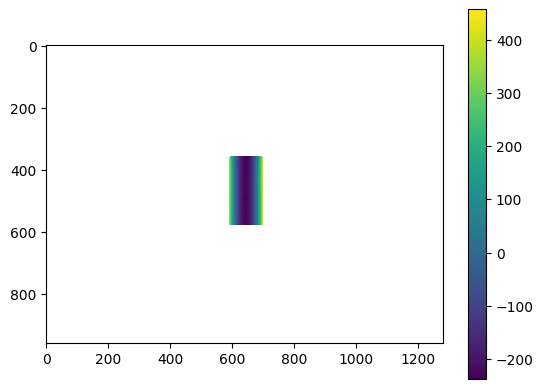

In [4]:
plt.figure()
plt.imshow(phase)
plt.colorbar()